In [316]:
# %% SECTION 1: Packages import
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Import other packages as necessary


In [317]:
# %% SECTION 2: Helper functions
# Define functions if needed


In [318]:
def gate_model(tau, x_0,x_inf,dt):
    y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))
    return y

#probably needs to be fixed, we need to make the gates opening dependent on voltage as well somehow
def get_current(e_r, g_bar, tau_m, tau_h,x_inf, v, t): 
    m = np.zeros(len(v))
    h = np.zeros(len(v))

    m[0] = 0
    h[0] = 1

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]

        m[i] = gate_model(tau_m, m[i-1], x_inf, dt)
        h[i] = gate_model(tau_h, h[i-1], x_inf, dt)

    return g_bar * (v - e_r) * m * h

def compute_error(params, t, v, test_i):
    e_r, g_bar, tau_m, tau_h,x_inf = params
    return get_current(e_r, g_bar, tau_m, tau_h, x_inf, v, t) - test_i


def gaussian(scale,center,width,v):
    return scale*np.exp(-((v-center)**2)/width)

def compute_error_tau(params,v,tau):
    scale,center,width = params
    return gaussian(scale,center,width,v) - tau # Gaussian formula

def sigmoid(steepness,center,v):
    return 1/(1+np.exp(-steepness*(v-center)))

def compute_error_x_inf(params,v,x_inf):
    steepness,center = params
    return sigmoid(steepness,center,v) - x_inf

def plot_x_inf(x_inf,v):
    fit = least_squares(compute_error_x_inf,args=(v,x_inf),x0=[1,0])

    voltages = [i for i in range(-100,21)]
    
    plt.figure()

    plt.subplot(1, 1, 1)
    plt.grid(True)
    plt.scatter(v, x_inf, linewidth=2)
    plt.plot(voltages,sigmoid(fit.x[0],fit.x[1],voltages))
    plt.ylabel("x_inf")
    plt.xlabel("Voltage (mV)")
    plt.legend()


def plot_taus(v,tau_m,tau_h):

    fit_m = least_squares(compute_error_tau, args = (v,tau_m), x0 = [3,20,5])
    fit_h = least_squares(compute_error_tau, args = (v,tau_h), x0 = [30,-40,5])

    voltages = [i for i in range(-100,21)]

    plt.figure()

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.scatter(v,tau_m, linewidth=2)
    plt.plot(voltages,gaussian(fit_m.x[0],fit_m.x[1],fit_m.x[2],voltages))
    plt.axis("tight")
    plt.ylabel("tau_m (msec)")

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.scatter(v, tau_h, linewidth=2)
    plt.plot(voltages,gaussian(fit_h.x[0],fit_h.x[1],fit_h.x[2],voltages))
    plt.ylabel("tau_h (msec)")
    plt.xlabel("Voltage (mV)")
    plt.legend()

Fitted parameters for V=-60.0, V=-100.0: [-7.80116376e+01  9.06201433e-01  1.28691653e-01  3.90058936e+01
  2.85587720e-03]
Fit succeeded: True
Fitted parameters for V=-100.0, V=-60.0: [-59.93845179   9.99501912   0.96726305   0.27497615   0.21274179]
Fitted parameters for V=-60.0, V=-40.0: [-50.5453925   -0.06828581   1.04000823   0.3558518    0.19198862]
Fit succeeded: True


C:\Users\liliy\AppData\Local\Temp\ipykernel_21336\185698716.py:2: RuntimeWarning: overflow encountered in scalar multiply
  y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))


Fitted parameters for V=-40.0, V=-60.0: [-5.99882767e+01  9.84423227e+00  9.84095404e-03  8.91060125e-01
  5.02646163e-01]
Fitted parameters for V=-60.0, V=-20.0: [-2.52191220e+01 -5.17069702e+00  1.58468740e+00  6.56911799e-01
  8.06935684e-04]
Fit succeeded: False
Fitted parameters for V=-20.0, V=-60.0: [-5.99911603e+01  9.99995447e+00  6.29307180e-03  1.73959383e+00
  5.13229522e-01]
Fitted parameters for V=-60.0, V=0.0: [ 3.29801719e+01 -5.78334966e-03  5.37287751e-01  3.12317609e-01
  2.99831186e-01]
Fit succeeded: True
Fitted parameters for V=0.0, V=-60.0: [-5.91976172e+01  9.02535537e+00  3.65379606e+00  7.99341747e-01
  5.34258882e-02]
Fitted parameters for V=-60.0, V=20.0: [ 4.65744101e+01 -2.64586376e+01  4.04859114e-01  1.57244170e+01
  4.29616300e-05]
Fit succeeded: False
Fitted parameters for V=20.0, V=-60.0: [-5.81806615e+01  8.93293130e+00  1.73780010e+01  6.62903624e-01
  3.54778379e-02]


C:\Users\liliy\AppData\Local\Temp\ipykernel_21336\185698716.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\liliy\AppData\Local\Temp\ipykernel_21336\185698716.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


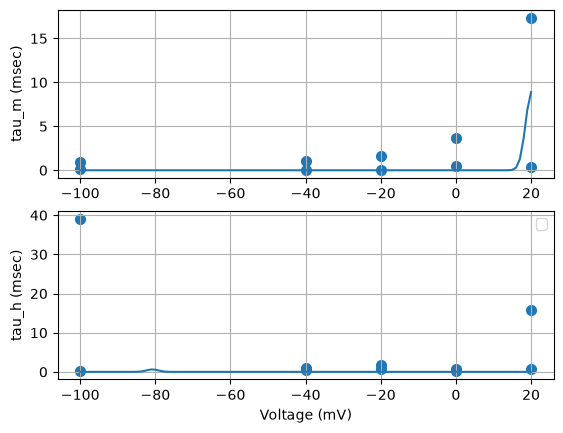

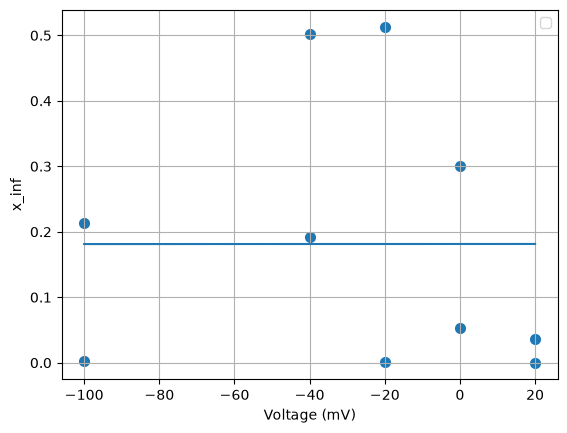

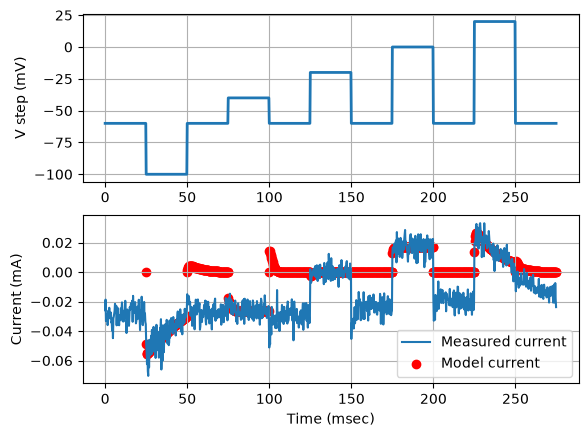

In [319]:
# %% SECTION 3: Main function
def run_vclamp_model(folder: str, data: str = "CookLab1UnknownChannelExtra.txt"):
    """
    Compute current from voltage-clamp input.

    Parameters
    ----------
    folder :
        Directory with input file for voltage-clamp model.
    data :
        Name of input file.
    # Please list any parameters added to the function.

    Returns
    -------
    np.ndarray
        Output current computed by the voltage-clamp model.
    """
    # %% SECTION 3-a: Load provided input data.
    # NO MODIFICATIONS: This section should be kept as is.
    data = np.loadtxt(os.path.join(folder, "data/CookLab1UnknownChannelExtra.txt"))
    tau_m = []
    tau_h = []
    tau_v = []
    list_i = []
    x_inf=[]
    past=1
    for j in range(1,11):
        start = j*100-past
        stop = (j+1)*100
        t = data[start:stop, 0]
        v = data[start:stop, 1]
        test_i = data[start:stop,2]


        # i has the same shape as array v, add code in the next section to fill it
        i = np.empty_like(v)

        # %% SECTION 3-b: Compute i [to be filled by students]
        
        fit = least_squares(compute_error, args = (t, v, test_i), x0 = [-60, 10, 1, 1,0.5])


        print(f"Fitted parameters for V={v[0]}, V={v[-1]}:", fit.x)
        if j%2 == 0:
            tau_v.append(tau_v[-1])
            tau_m.append(fit.x[2])
            tau_h.append(fit.x[3])
            x_inf.append(fit.x[4])
        else:
            tau_m.append(fit.x[2])
            tau_h.append(fit.x[3])
            tau_v.append(v[past])
            x_inf.append(fit.x[4])
            print("Fit succeeded:", fit.success)    
            
            i = get_current(*fit.x, v, t)
        list_i+=list(i)

    plot_taus(tau_v,tau_m,tau_h)
    plot_x_inf(x_inf,tau_v)
    t = data[:, 0]
    v = data[:, 1]
    test_i = data[:,2]

    plt.figure()

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(t[:1100], v[:1100], linewidth=2)
    plt.axis("tight")
    plt.ylabel("V step (mV)")

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(t[:1100], test_i[:1100], label="Measured current")
    t = []
    for j in range(1,11):
        start = j*100-past
        stop = (j+1)*100
        
        # if j%2==1:
        t += list(data[start:stop, 0])
    plt.scatter(t, list_i, label="Model current",color="r")
    plt.xlabel("Time (msec)")
    plt.ylabel("Current (mA)")
    plt.legend()

    # %% SECTION 3-c: Assert validity of output and return it.
    # NO MODIFICATIONS: This section should be kept as is.
    assert len(i.shape) == 1, "Currrent array should be 1-dimensional"
    return i

fitted = run_vclamp_model(os.getcwd())


Fitted parameters for V=-60.0, V=-100.0: [-7.80116376e+01  9.06201433e-01  1.28691653e-01  3.90058936e+01
  2.85587720e-03]
Fit succeeded: True
Fitted parameters for V=-100.0, V=-60.0: [-59.93845179   9.99501912   0.96726305   0.27497615   0.21274179]
Fitted parameters for V=-60.0, V=-40.0: [-50.5453925   -0.06828581   1.04000823   0.3558518    0.19198862]
Fit succeeded: True


C:\Users\liliy\AppData\Local\Temp\ipykernel_21336\185698716.py:2: RuntimeWarning: overflow encountered in scalar multiply
  y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))


Fitted parameters for V=-40.0, V=-60.0: [-5.99882767e+01  9.84423227e+00  9.84095404e-03  8.91060125e-01
  5.02646163e-01]
Fitted parameters for V=-60.0, V=-20.0: [-2.52191220e+01 -5.17069702e+00  1.58468740e+00  6.56911799e-01
  8.06935684e-04]
Fit succeeded: False
Fitted parameters for V=-20.0, V=-60.0: [-5.99911603e+01  9.99995447e+00  6.29307180e-03  1.73959383e+00
  5.13229522e-01]
Fitted parameters for V=-60.0, V=0.0: [ 3.29801719e+01 -5.78334966e-03  5.37287751e-01  3.12317609e-01
  2.99831186e-01]
Fit succeeded: True
Fitted parameters for V=0.0, V=-60.0: [-5.91976172e+01  9.02535537e+00  3.65379606e+00  7.99341747e-01
  5.34258882e-02]
Fitted parameters for V=-60.0, V=20.0: [ 4.65744101e+01 -2.64586376e+01  4.04859114e-01  1.57244170e+01
  4.29616300e-05]
Fit succeeded: False
Fitted parameters for V=20.0, V=-60.0: [-5.81806615e+01  8.93293130e+00  1.73780010e+01  6.62903624e-01
  3.54778379e-02]


C:\Users\liliy\AppData\Local\Temp\ipykernel_21336\185698716.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\liliy\AppData\Local\Temp\ipykernel_21336\185698716.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


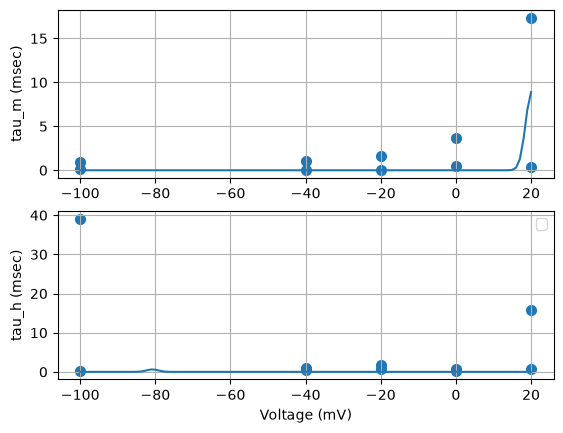

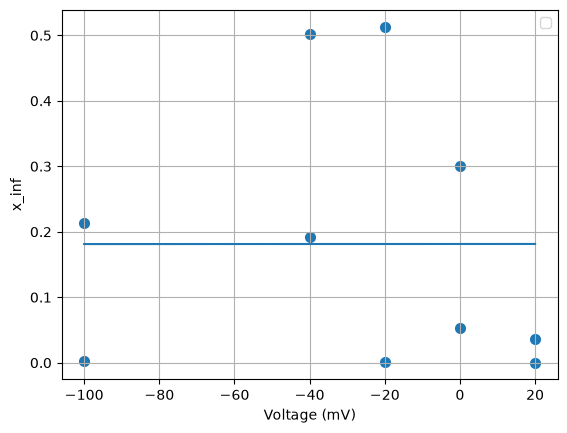

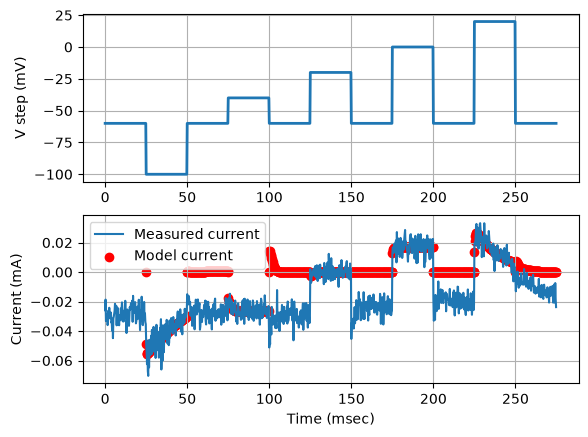

In [320]:
# %% SECTION 4: Function calls
if __name__ == "__main__":
    # Replace this with the path to the folder where provided input .txt file is!
    folder = ""

    # Run function on the voltage-clamp data
    i = run_vclamp_model(folder)